**Random Forest**

**1.Exploratory Data Analysis**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
excel_file=pd.ExcelFile('glass.xlsx')
print(excel_file.sheet_names)

['Description', 'glass']


In [3]:
df=pd.read_excel('glass.xlsx',sheet_name='glass')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [4]:
print(df.shape)

(214, 10)


In [5]:
print(df.columns.tolist())

['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [7]:
#stat summary
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


In [8]:
#missing values
print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [9]:
#duplicate value
df.duplicated().sum()

np.int64(1)

In [10]:
# Check number of unique values in each column
print("Unique values in each column:")
print(df.nunique())

# Display unique values of target column
print("\nUnique Glass Types:")
print(df["Type"].unique())

Unique values in each column:
RI      178
Na      142
Mg       94
Al      118
Si      133
K        65
Ca      143
Ba       34
Fe       32
Type      6
dtype: int64

Unique Glass Types:
[1 2 3 5 6 7]


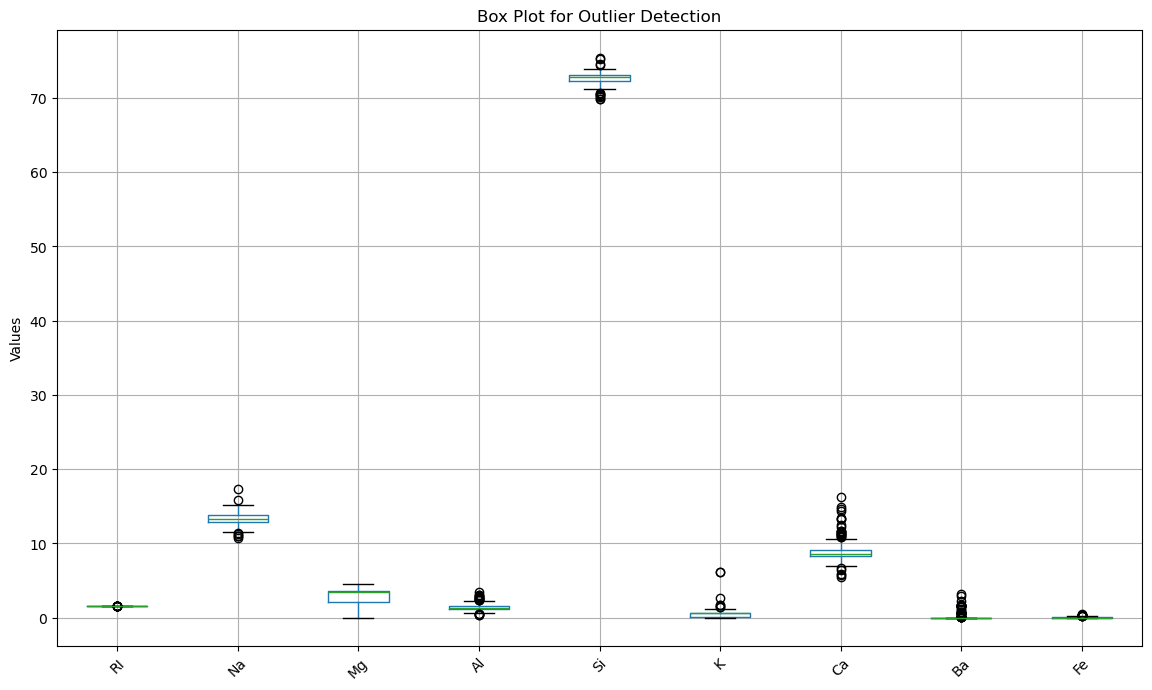

In [11]:
# Select numerical columns except target
numeric_columns = df.select_dtypes(include=np.number).columns.drop("Type")

# Create boxplots
plt.figure(figsize=(14, 8))
df[numeric_columns].boxplot()
plt.title("Box Plot for Outlier Detection")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()

In [12]:
# Calculate outliers using IQR method

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]
    print(column, ":", len(outliers), "outliers")

RI : 17 outliers
Na : 7 outliers
Mg : 0 outliers
Al : 18 outliers
Si : 12 outliers
K : 7 outliers
Ca : 26 outliers
Ba : 38 outliers
Fe : 12 outliers


Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


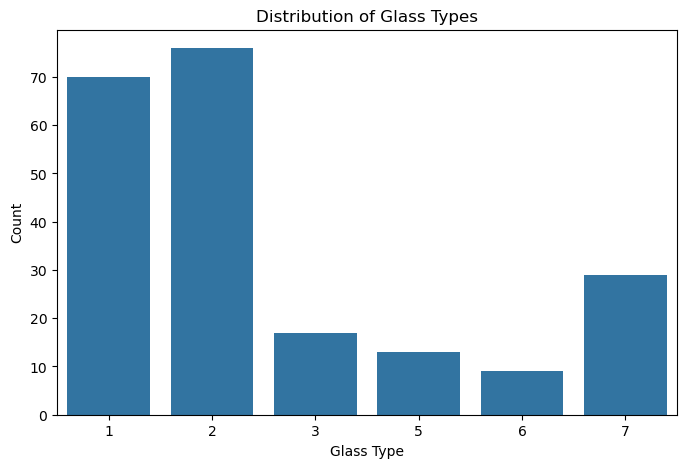

In [13]:
# Check distribution of Glass Types
print(df["Type"].value_counts())

# Visualize target distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="Type", data=df)
plt.title("Distribution of Glass Types")
plt.xlabel("Glass Type")
plt.ylabel("Count")
plt.show()

**2.Data Visualization**

Histogram

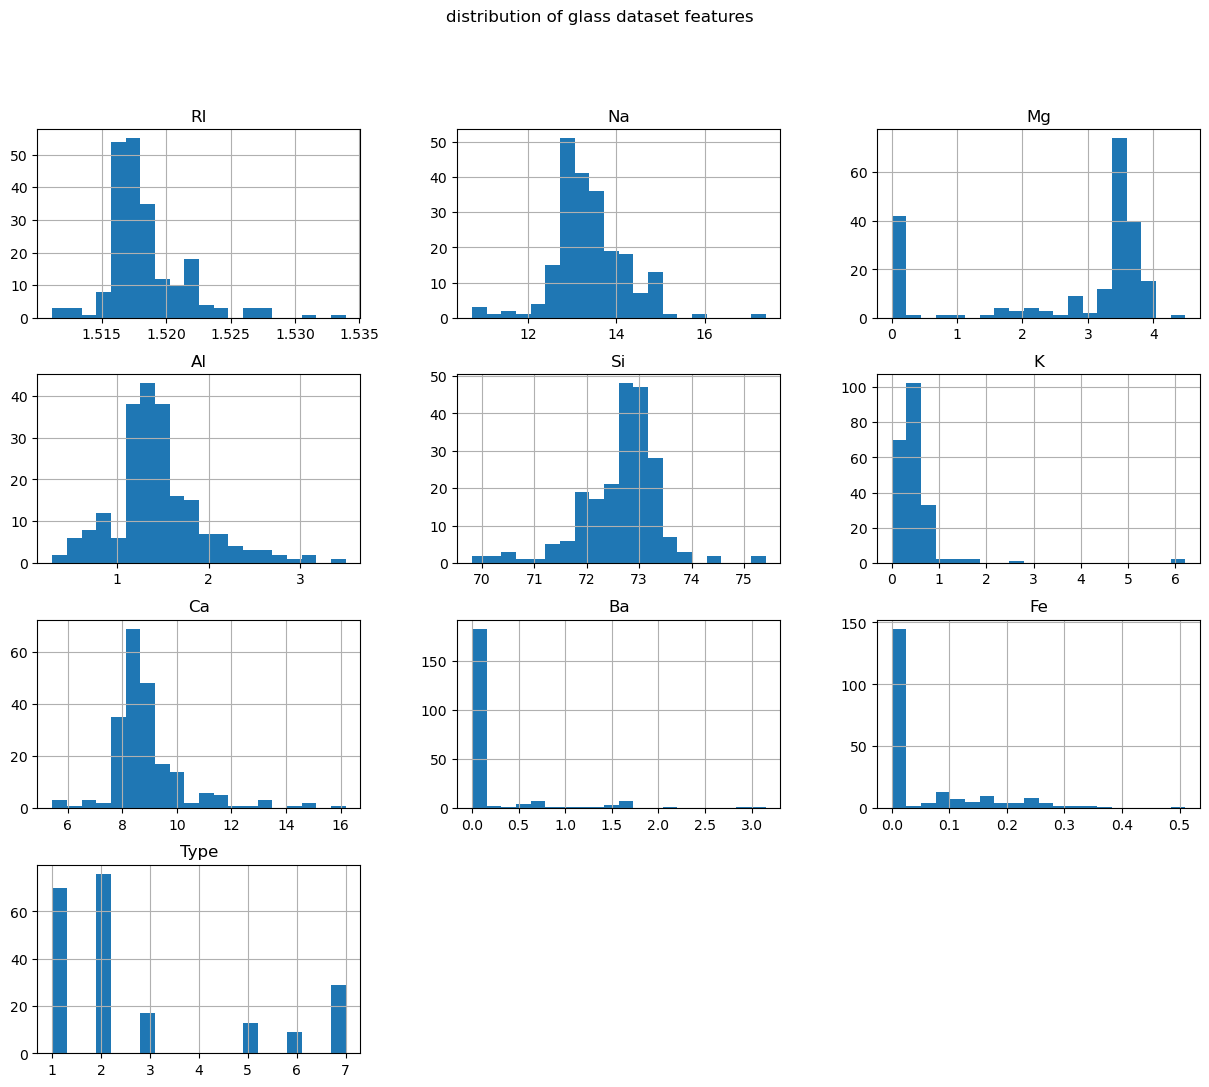

In [14]:
df.hist(figsize=(15,12),bins=20)
plt.suptitle('distribution of glass dataset features')
plt.show()

Histograms show the distribution of each numerical feature.
Some features may be skewed rather than normally distributed.
The features have different ranges, so scaling can be considered during preprocessing.

Box Plot

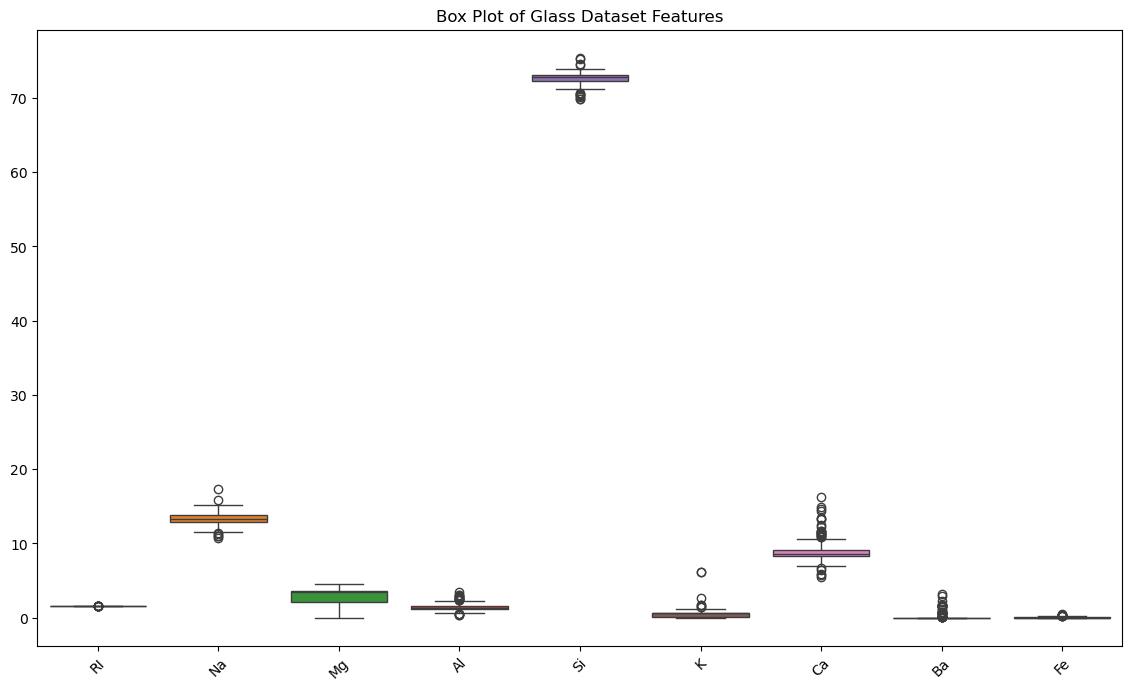

In [15]:
# Select numerical features
numeric_columns = df.select_dtypes(include=np.number).columns.drop("Type")

# Create box plots
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[numeric_columns])
plt.title("Box Plot of Glass Dataset Features")
plt.xticks(rotation=45)
plt.show()

Box plots help identify possible outliers.
Some features contain observations outside the normal range.
Since Random Forest is relatively robust to outliers, we do not necessarily need to remove them unless they are data-entry errors.

Pair plot

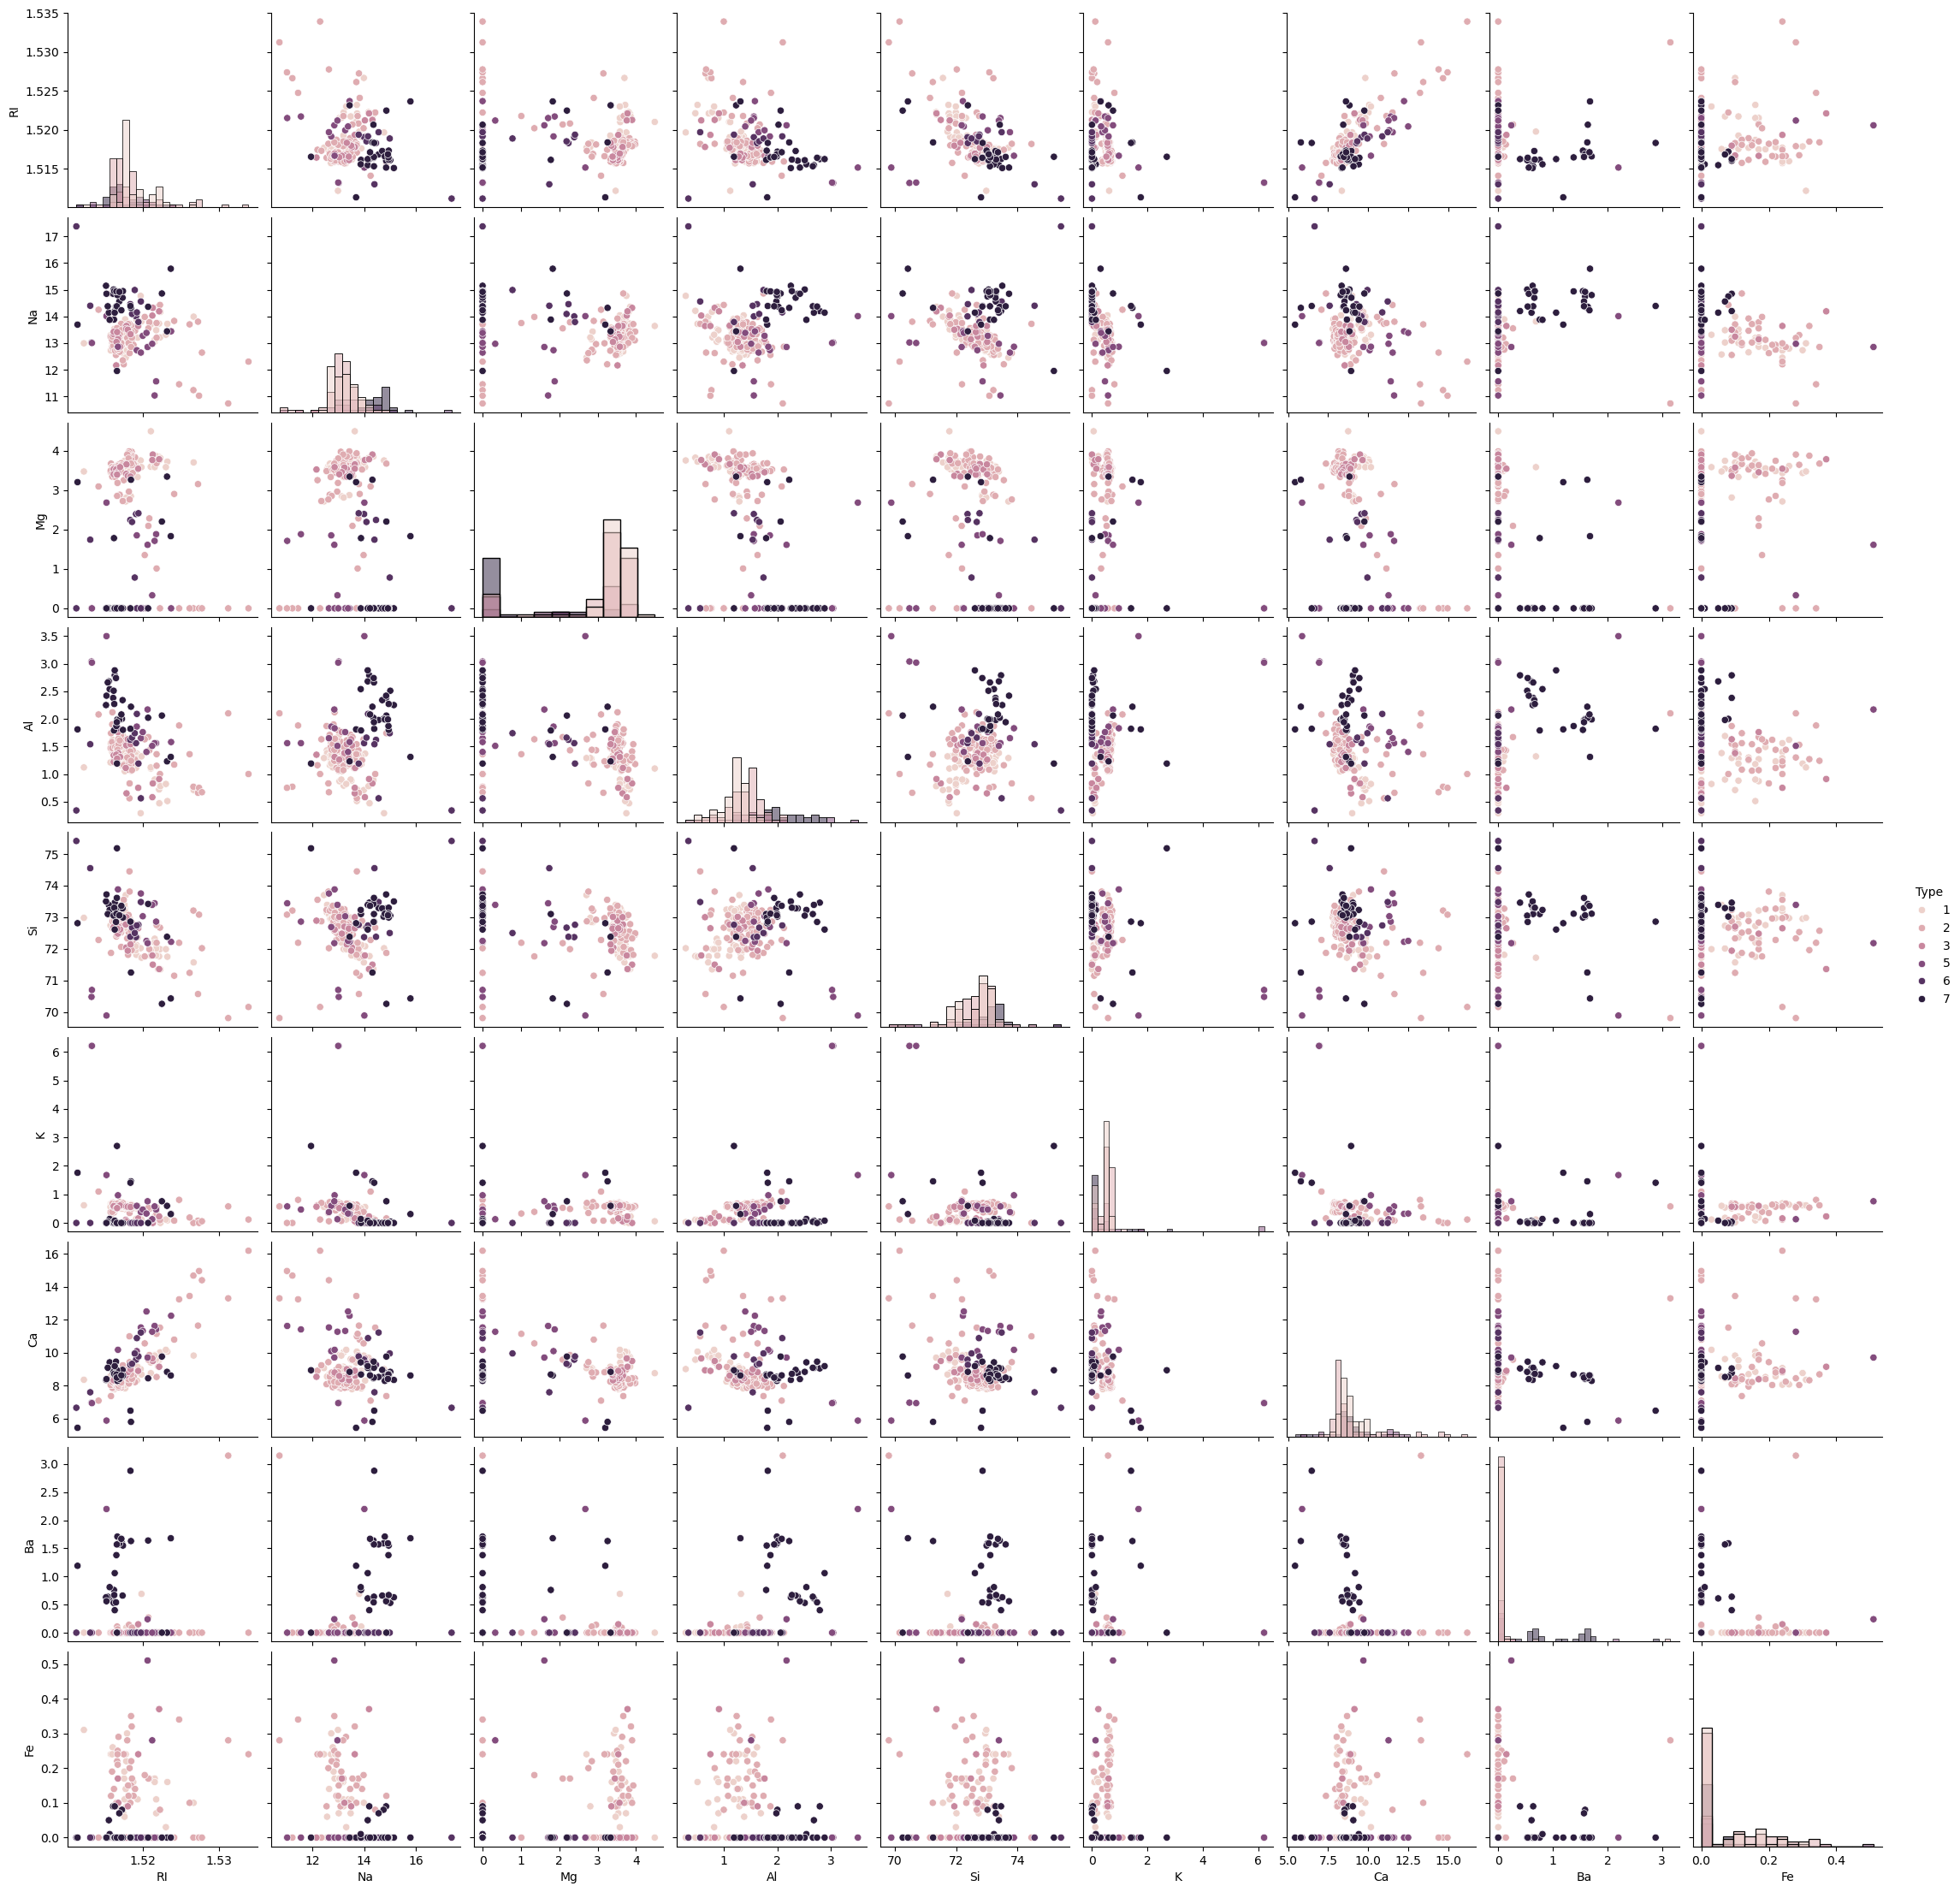

In [16]:
sns.pairplot(
    df,
    vars=numeric_columns,
    hue='Type',
    diag_kind='hist'
)
plt.show()

Pair plots show relationships between different features.
Some glass types form partially separated groups.
Some features have stronger relationships with each other than others.

Correlation Heatmap

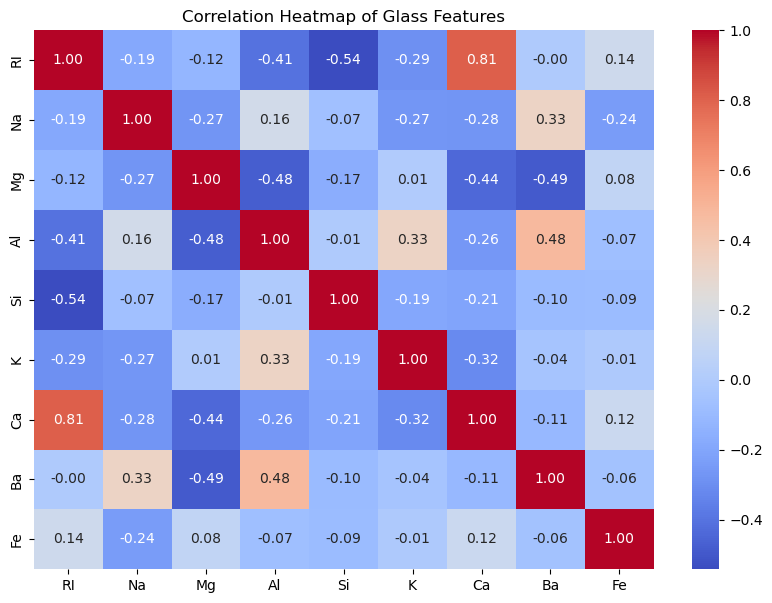

In [17]:
correlation = df[numeric_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Glass Features")
plt.show()

The heatmap shows the strength of relationships between numerical features.
A value close to +1 indicates strong positive correlation.
A value close to -1 indicates strong negative correlation.
A value close to 0 indicates weak correlation.
Highly correlated features may contain similar information.

**Data Preprocessing**

In [18]:
print(df.isnull().sum())

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [19]:
# Fill missing numerical values using median
for column in df.select_dtypes(include=np.number).columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())
print("Missing values after handling:")
print(df.isnull().sum())

Missing values after handling:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


Median imputation is used because it is less affected by outliers than the mean. If the dataset has no missing values, no imputation is actually required.

categorical variable

In [20]:
# Check categorical columns
categorical_columns = df.select_dtypes(include="object").columns
print("Categorical columns:")
print(categorical_columns)

Categorical columns:
Index([], dtype='object')


In [21]:
# Example of one-hot encoding categorical input features
X = df.drop("Type", axis=1)
X = pd.get_dummies(X, drop_first=True)
X.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0


In [22]:
# Separate independent variables and target variable

X = df.drop("Type", axis=1)
y = df["Type"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (214, 9)
Target shape: (214,)


In [23]:
# Check number of samples in each class
print(y.value_counts())
# Check class proportions
print("\nClass proportions:")
print(y.value_counts(normalize=True))

Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

Class proportions:
Type
2    0.355140
1    0.327103
7    0.135514
3    0.079439
5    0.060748
6    0.042056
Name: proportion, dtype: float64


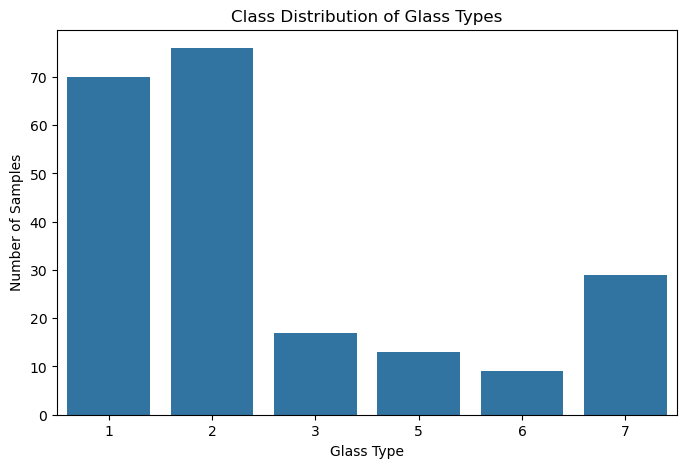

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("Class Distribution of Glass Types")
plt.xlabel("Glass Type")
plt.ylabel("Number of Samples")
plt.show()

Handle imbalanced data

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print(X_train.shape)
print(X_test.shape)

(171, 9)
(43, 9)


In [27]:
from sklearn.ensemble import RandomForestClassifier
# Random Forest with class balancing
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


class_weight="balanced" gives more importance to minority classes and helps the model avoid being biased toward the majority class.

Feature Scaling-Standardization

In [28]:
from sklearn.preprocessing import StandardScaler


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training data:")
print(X_train_scaled[:5])

Scaled training data:
[[-0.64297515 -1.70597847 -1.94121956 -0.50113818  3.21540115  3.98983951
  -0.02007105 -0.34453523 -0.61924279]
 [ 1.18233317  1.0023666   0.76682837 -1.97969397 -1.1041228  -0.68405691
   0.448282   -0.34453523 -0.61924279]
 [-0.26813505 -0.86711053  0.58251097 -0.27524771  0.55528376  0.21823969
  -0.19570345 -0.34453523  0.73957227]
 [ 1.21492796 -0.19601618  0.73138271 -1.32255806 -0.82544383 -0.64796505
   0.77759274 -0.34453523 -0.61924279]
 [-0.00737672  0.31928842  0.80227402 -0.33685421 -0.86344551  0.09191817
  -0.46647005 -0.34453523  2.48662021]]


In [30]:
print("Missing values:")
print(df.isnull().sum())
print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("\nClass distribution:")
print(y.value_counts())

Missing values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Training data shape: (171, 9)
Testing data shape: (43, 9)

Class distribution:
Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


In [31]:
# Import train_test_split

from sklearn.model_selection import train_test_split
# Separate features and target
X = df.drop("Type", axis=1)
y = df["Type"]
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (171, 9)
Testing data: (43, 9)


In [32]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
print(rf_model)

RandomForestClassifier(class_weight='balanced', random_state=42)


In [33]:
#train the model
rf_model.fit(X_train,y_train)
print('Random forest model trained successfully')

Random forest model trained successfully


In [35]:
y_pred_rf=rf_model.predict(X_test)
print('predicted values:')
print(y_pred_rf)

predicted values:
[7 5 2 5 1 2 2 5 1 1 3 1 7 6 1 7 7 1 1 5 2 1 7 2 1 1 2 6 2 1 2 1 1 2 2 2 1
 1 2 3 1 2 6]


In [36]:
# Import evaluation metrics

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test, y_pred_rf,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test, y_pred_rf,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test, y_pred_rf,
    average="weighted",
    zero_division=0
)
print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Random Forest Performance
-------------------------
Accuracy : 0.7441860465116279
Precision: 0.7499254621347645
Recall   : 0.7441860465116279
F1 Score : 0.739695962951777


In [37]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

           1       0.69      0.79      0.73        14
           2       0.77      0.67      0.71        15
           3       0.50      0.33      0.40         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.73      0.77      0.74        43
weighted avg       0.75      0.74      0.74        43



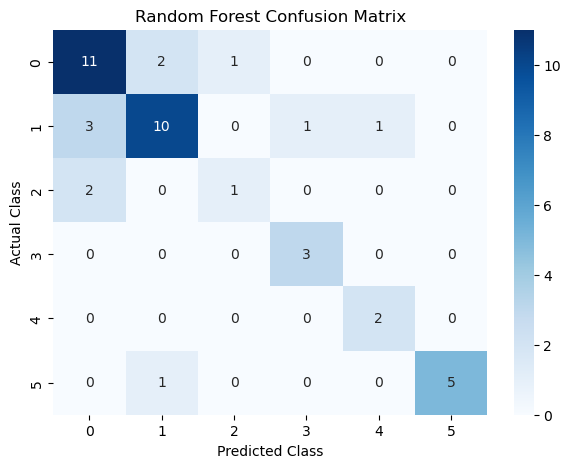

In [38]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(7, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

**5.Bagging and Boosting Methods**

Bagging Classifier

In [41]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

In [49]:
#create base decision tree
base_model=DecisionTreeClassifier(random_state=42)

In [44]:
bagging_model=BaggingClassifier(
    estimator=base_model,
    n_estimators=100,
    random_state=42
)

In [50]:
#train bagging model
bagging_model.fit(X_train,y_train)

,estimator,DecisionTreeC...ndom_state=42)
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [46]:
y_pred_bagging=bagging_model.predict(X_test)

In [48]:
bagging_accuracy=accuracy_score(y_test,y_pred_bagging)
print(bagging_accuracy)

0.813953488372093


AdaBoost

In [57]:
# Import AdaBoost
from sklearn.ensemble import AdaBoostClassifier

In [58]:
# Create AdaBoost model
boosting_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)


In [59]:
# Train the model
boosting_model.fit(X_train, y_train)


,estimator,None
,n_estimators,100
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,42


In [60]:
# Make predictions
y_pred_boosting = boosting_model.predict(X_test)


In [61]:
# Calculate accuracy
boosting_accuracy = accuracy_score(
    y_test,
    y_pred_boosting
)
print("AdaBoost Accuracy:", boosting_accuracy)

AdaBoost Accuracy: 0.3953488372093023


In [62]:
# Calculate precision, recall and F1-score for Bagging
bagging_precision = precision_score(
    y_test, y_pred_bagging,
    average="weighted",
    zero_division=0
)
bagging_recall = recall_score(
    y_test, y_pred_bagging,
    average="weighted",
    zero_division=0
)
bagging_f1 = f1_score(
    y_test, y_pred_bagging,
    average="weighted",
    zero_division=0
)




In [63]:
# Calculate precision, recall and F1-score for AdaBoost
boosting_precision = precision_score(
    y_test, y_pred_boosting,
    average="weighted",
    zero_division=0
)
boosting_recall = recall_score(
    y_test, y_pred_boosting,
    average="weighted",
    zero_division=0
)
boosting_f1 = f1_score(
    y_test, y_pred_boosting,
    average="weighted",
    zero_division=0
)

In [68]:
# Create model comparison table
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Bagging",
        "AdaBoost"
    ],
    "Accuracy": [
        rf_accuracy,
        bagging_accuracy,
        boosting_accuracy
    ],
    "Precision": [
        rf_precision,
        bagging_precision,
        boosting_precision
    ],
    "Recall": [
        rf_recall,
        bagging_recall,
        boosting_recall
    ],
    "F1 Score": [
        rf_f1,
        bagging_f1,
        boosting_f1
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.744186,0.749925,0.744186,0.739696
1,Bagging,0.813953,0.822523,0.813953,0.811869
2,AdaBoost,0.395349,0.466667,0.395349,0.363817


Visualize Model Comparision

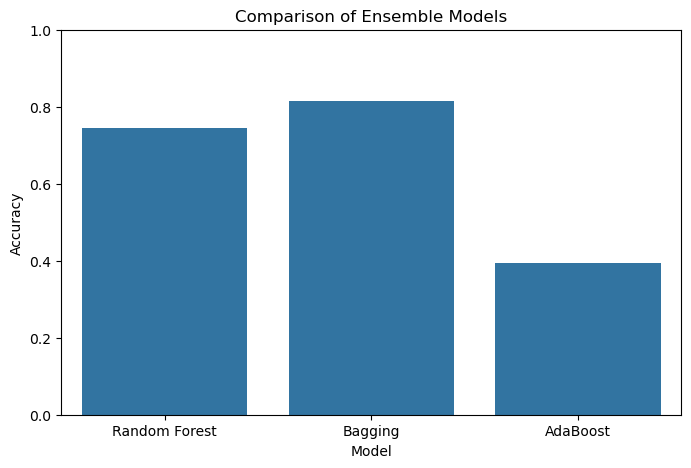

In [69]:
# Plot model accuracy comparison
plt.figure(figsize=(8, 5))
sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison
)
plt.title("Comparison of Ensemble Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

1. Explain Bagging and Boosting methods. How is it different from each other.

Bagging:

Bagging stands for Bootstrap Aggregating.
It creates multiple training datasets by randomly sampling the original data.
Multiple models are trained independently and in parallel.
Their predictions are combined to produce the final prediction.
It mainly helps to reduce variance and overfitting.
Random Forest is a popular example of a bagging-based ensemble method.

Boosting:

Boosting is an ensemble technique where models are trained sequentially.
The first model is trained on the data.
The next model focuses more on observations that were incorrectly predicted.
This process continues for several models.
The models are then combined to produce the final prediction.
It mainly helps to reduce bias and improve accuracy.
AdaBoost, Gradient Boosting and XGBoost are examples of boosting methods.

->Bagging : many models learn independently and then vote

->Boosting : models learn o

2. Explain how to handle imbalance in the data.

Imbalanced:Imbalanced data occurs when some classes have many more observations than other classes.

Methods to Handle Imbalanced Data::

1. Stratified Train-Test Split
   
Use stratify=y so that the training and testing sets maintain similar class proportions.


3. Class Weight

For Random Forest, we can give more importance to minority classes.

3. Oversampling

Oversampling increases the number of minority-class samples.
A common technique is SMOTE (Synthetic Minority Oversampling Technique).

4. Undersampling

Undersampling reduces the number of majority-class samples so that the classes become more balanced.

5. Use Suitable Evaluation Metrics


For imbalanced datasets, don't rely only on accuracy. Also check:
Precision
Recall
F1-score
Confusion Matrix
